## **Wavelet Phase Transition Detector**

Using scales from 5 to 50
Signal frequency: 5 Hz
Expected scale for main frequency: ~10.0
CWT successful! Coefficient shapes: (30, 1000)
Frequency range: 2.00 - 20.00 Hz
Max coefficient magnitude: 4.582
Analyzing transitions at 4.87 Hz (closest to 5 Hz)
Found transition at t=5.01s: In-phase → Out-of-phase
  Before: 0.35 rad, After: 2.84 rad

=== PHASE TRANSITIONS DETECTED ===
Transition 1: In-phase → Out-of-phase at t = 5.01 seconds


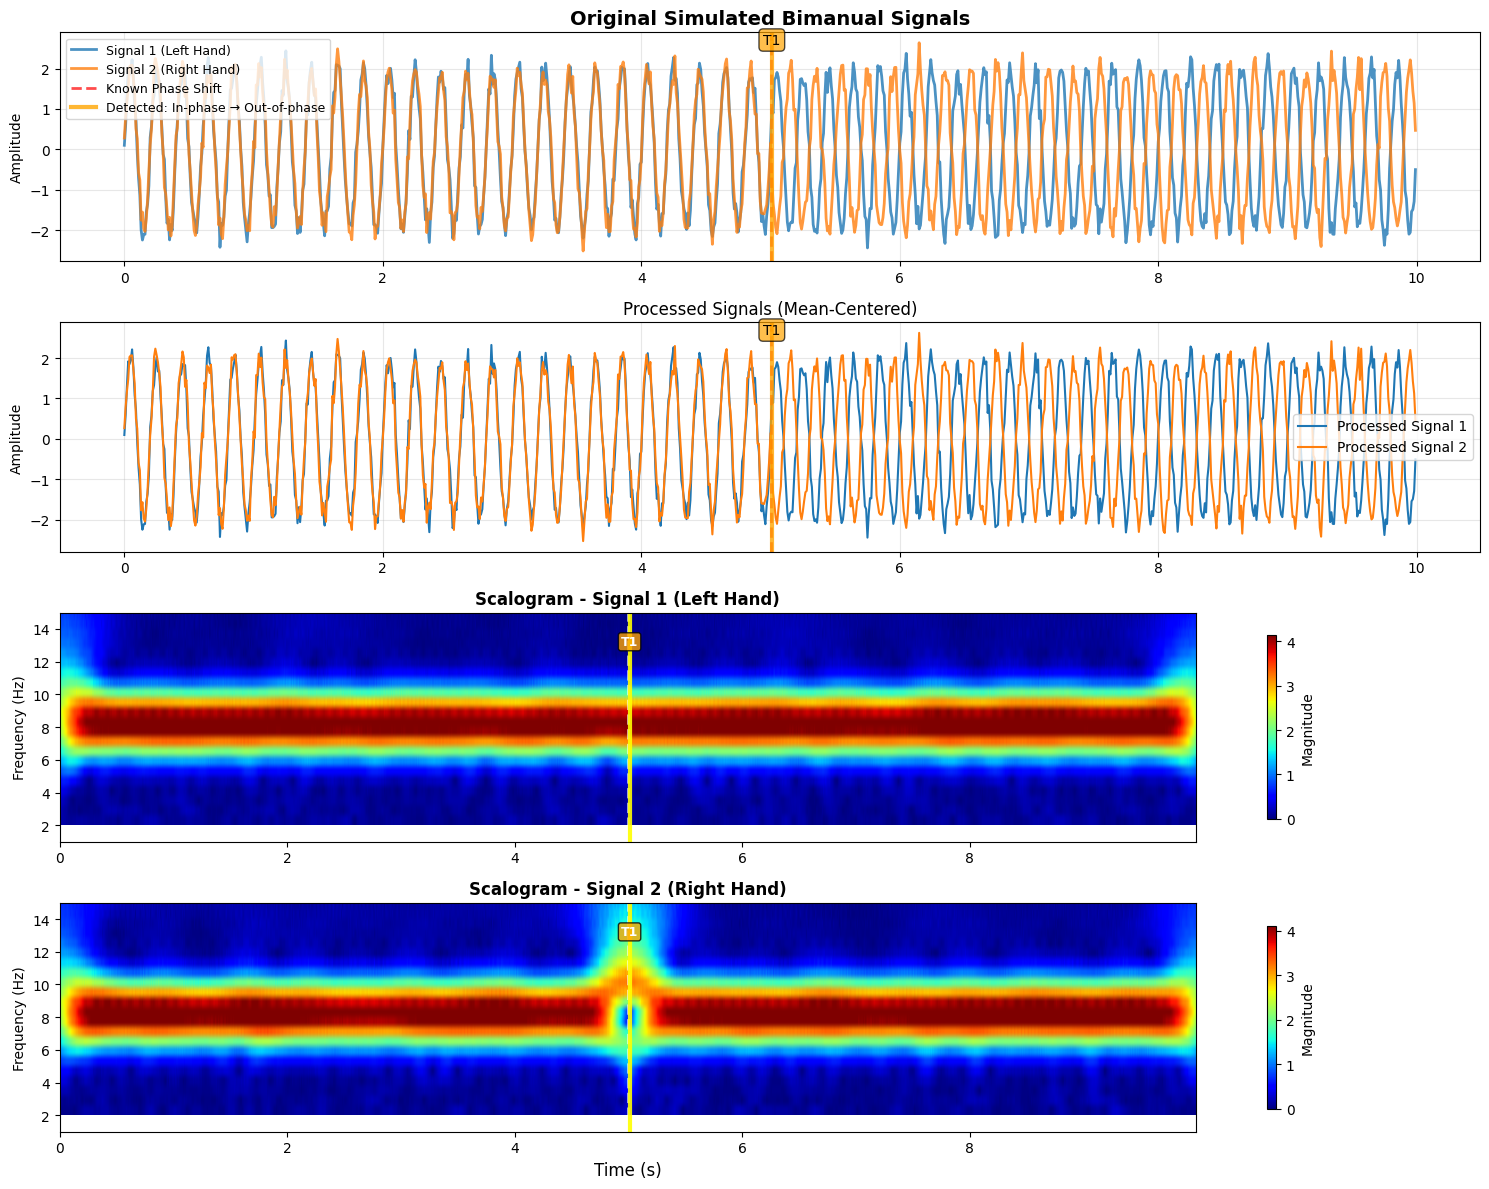

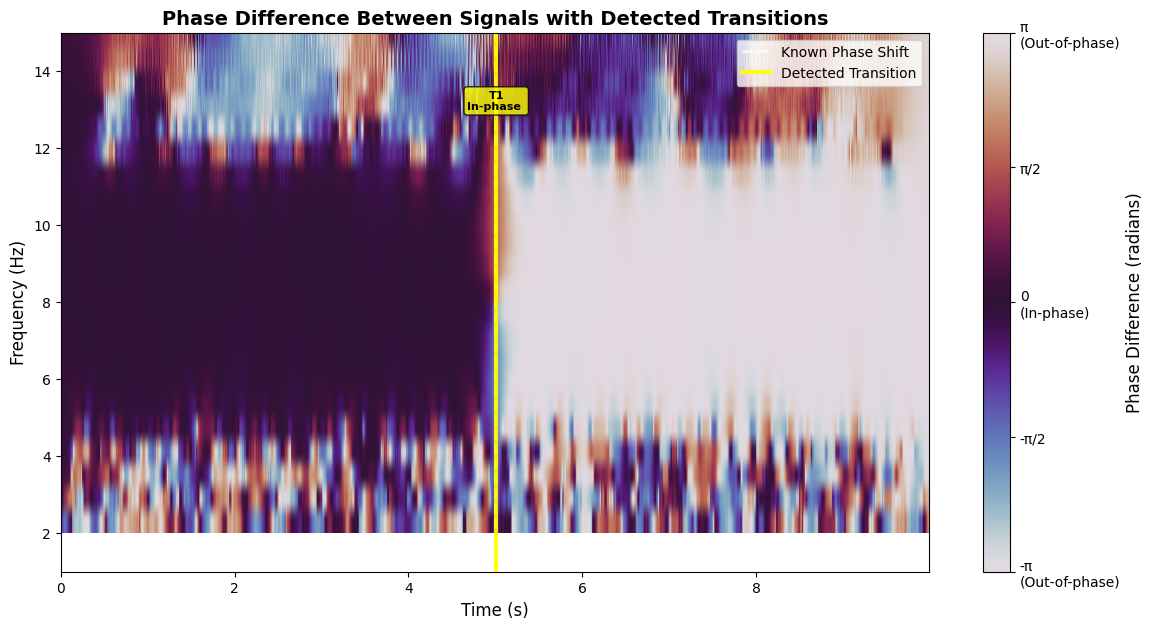

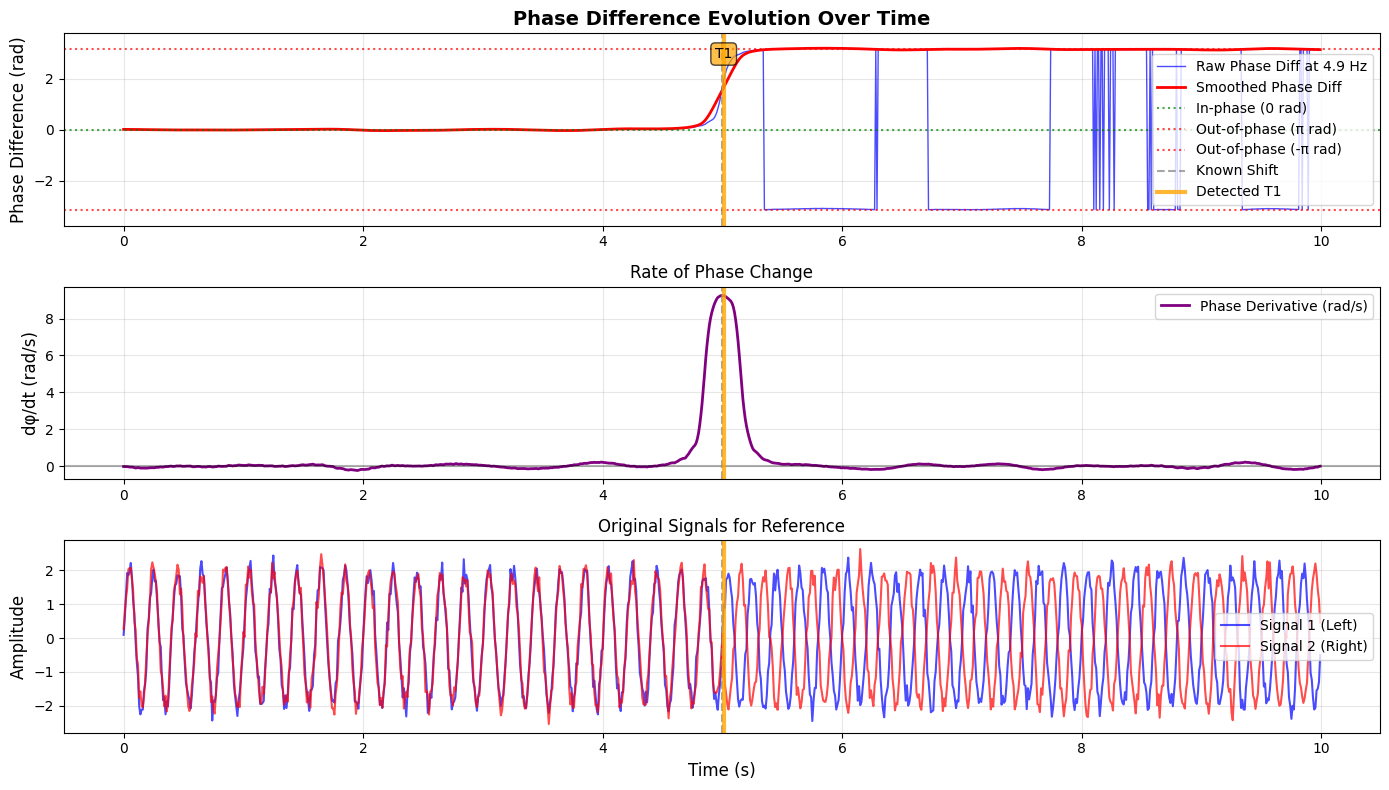


=== DIAGNOSTIC INFORMATION ===
Signal 1 stats: mean=0.004, std=1.424
Signal 2 stats: mean=0.014, std=1.417
Wavelet coefficients range: 0.001102 to 4.582289
Main frequency (5 Hz) analyzed at: 4.87 Hz
Energy at main frequency over time: max = 4.582
Phase difference before shift: 0.03 rad
Phase difference after shift: 3.16 rad
Expected change: 0 → ±π radians

=== PERFORMANCE SUMMARY ===
Expected transition at: 5 seconds
Closest detected transition at: 5.01 seconds
Detection error: 0.01 seconds
✓ Good detection accuracy!


In [8]:
import numpy as np
import pywt
import matplotlib.pyplot as plt
from scipy.signal import detrend
from scipy.ndimage import uniform_filter1d

# --- 1. Simulate/Load Data with clearer parameters ---
fs = 100  # Sampling frequency (Hz)
duration_s = 10  # Total duration of the signal in seconds
t = np.linspace(0, duration_s, int(duration_s * fs), endpoint=False)

# Create stronger, cleaner signals
freq_osc = 5  # Hz, the base frequency of oscillation
amplitude = 2.0  # Increased amplitude

# Signal 1 (Left Hand) - simple sine wave
signal1 = amplitude * np.sin(2 * np.pi * freq_osc * t)

# Signal 2 (Right Hand) - phase shift at 5 seconds
signal2 = np.zeros_like(t)
phase_shift_time = 5  # seconds
phase_shift_idx = t >= phase_shift_time

# In-phase for first half, out-of-phase for second half
signal2[~phase_shift_idx] = amplitude * np.sin(2 * np.pi * freq_osc * t[~phase_shift_idx])
signal2[phase_shift_idx] = amplitude * np.sin(2 * np.pi * freq_osc * t[phase_shift_idx] + np.pi)

# Add moderate noise
np.random.seed(42)
noise_level = 0.2  # Reduced noise level
signal1 += np.random.normal(0, noise_level, len(t))
signal2 += np.random.normal(0, noise_level, len(t))

# --- 2. Minimal preprocessing ---
# Just center the signals (don't over-normalize initially)
signal1_proc = signal1 - np.mean(signal1)
signal2_proc = signal2 - np.mean(signal2)

# --- 3. Simple CWT Parameters ---
wavelet = 'cmor1.5-1.0'

# Use a simple approach: define scales directly
# For a 5 Hz signal with fs=100, we want scales around 20
min_scale = 5    # Will capture high frequencies
max_scale = 50   # Will capture low frequencies  
num_scales = 30
scales = np.linspace(min_scale, max_scale, num_scales)

print(f"Using scales from {min_scale} to {max_scale}")
print(f"Signal frequency: {freq_osc} Hz")
print(f"Expected scale for main frequency: ~{fs/(2*freq_osc)}")

# --- 4. Perform CWT ---
try:
    coef1, freqs1 = pywt.cwt(signal1_proc, scales, wavelet, sampling_period=1/fs)
    coef2, freqs2 = pywt.cwt(signal2_proc, scales, wavelet, sampling_period=1/fs)
    print(f"CWT successful! Coefficient shapes: {coef1.shape}")
    print(f"Frequency range: {freqs1.min():.2f} - {freqs1.max():.2f} Hz")
    print(f"Max coefficient magnitude: {np.abs(coef1).max():.3f}")
except Exception as e:
    print(f"CWT failed: {e}")
    raise

# --- 5. Phase Analysis and Transition Detection ---
# Calculate cross-wavelet transform
cross_wavelet = coef1 * np.conj(coef2)
phase_diff = np.angle(cross_wavelet)

def detect_phase_transitions(phase_diff, freqs, t, target_freq=5, threshold=2.0):
    """
    Detect phase transitions in the wavelet phase difference data.
    
    Parameters:
    - phase_diff: 2D array of phase differences (freq x time)
    - freqs: frequency array
    - t: time array
    - target_freq: frequency to analyze for phase transitions
    - threshold: minimum phase change to consider a transition (radians)
    
    Returns:
    - transition_times: list of times where transitions occur
    - transition_types: list of transition descriptions
    """
    # Find frequency bin closest to target frequency
    freq_idx = np.argmin(np.abs(freqs - target_freq))
    actual_freq = freqs[freq_idx]
    print(f"Analyzing transitions at {actual_freq:.2f} Hz (closest to {target_freq} Hz)")
    
    # Extract phase difference at target frequency
    phase_at_freq = phase_diff[freq_idx, :]
    
    # Unwrap phase to handle discontinuities
    phase_unwrapped = np.unwrap(phase_at_freq)
    
    # Smooth phase slightly to reduce noise
    window_size = max(1, int(0.3 * fs))  # 0.3 second smoothing window
    phase_smooth = uniform_filter1d(phase_unwrapped, size=window_size)
    
    # Calculate phase derivative (rate of change)
    phase_derivative = np.gradient(phase_smooth, t)
    
    # Find significant phase jumps by looking for large absolute derivatives
    derivative_threshold = threshold  # radians per second
    large_changes = np.abs(phase_derivative) > derivative_threshold
    change_indices = np.where(large_changes)[0]
    
    transition_times = []
    transition_types = []
    
    if len(change_indices) > 0:
        # Group nearby changes together (within 0.5 seconds)
        change_groups = []
        current_group = [change_indices[0]]
        
        for idx in change_indices[1:]:
            if t[idx] - t[current_group[-1]] < 0.5:  # Within 0.5 seconds
                current_group.append(idx)
            else:
                change_groups.append(current_group)
                current_group = [idx]
        change_groups.append(current_group)
        
        # Process each group of changes
        for group in change_groups:
            transition_idx = group[len(group)//2]  # Middle of the group
            transition_time = t[transition_idx]
            
            # Determine transition type based on phase values before/after
            window = int(0.5 * fs)  # 0.5 second window
            before_start = max(0, transition_idx - window)
            after_end = min(len(phase_smooth), transition_idx + window)
            
            before_phase = np.mean(phase_smooth[before_start:transition_idx])
            after_phase = np.mean(phase_smooth[transition_idx:after_end])
            
            # Wrap phases to [-π, π] for comparison
            before_phase_wrapped = ((before_phase + np.pi) % (2*np.pi)) - np.pi
            after_phase_wrapped = ((after_phase + np.pi) % (2*np.pi)) - np.pi
            
            # Classify the transition
            if abs(before_phase_wrapped) < np.pi/3 and abs(after_phase_wrapped) > 2*np.pi/3:
                transition_type = "In-phase → Out-of-phase"
            elif abs(before_phase_wrapped) > 2*np.pi/3 and abs(after_phase_wrapped) < np.pi/3:
                transition_type = "Out-of-phase → In-phase"
            else:
                phase_change = after_phase_wrapped - before_phase_wrapped
                transition_type = f"Phase shift ({phase_change:.2f} rad)"
            
            transition_times.append(transition_time)
            transition_types.append(transition_type)
            
            print(f"Found transition at t={transition_time:.2f}s: {transition_type}")
            print(f"  Before: {before_phase_wrapped:.2f} rad, After: {after_phase_wrapped:.2f} rad")
    
    return transition_times, transition_types, phase_smooth, freq_idx

# Detect transitions BEFORE plotting
transition_times, transition_types, phase_smooth, freq_idx = detect_phase_transitions(phase_diff, freqs1, t)

print(f"\n=== PHASE TRANSITIONS DETECTED ===")
if len(transition_times) > 0:
    for i, (time, trans_type) in enumerate(zip(transition_times, transition_types)):
        print(f"Transition {i+1}: {trans_type} at t = {time:.2f} seconds")
else:
    print("No transitions detected with current parameters")

# --- 6. Plot everything with better scaling ---
fig, axes = plt.subplots(4, 1, figsize=(15, 12))

# Plot original signals
axes[0].plot(t, signal1, label='Signal 1 (Left Hand)', linewidth=2, alpha=0.8)
axes[0].plot(t, signal2, label='Signal 2 (Right Hand)', linewidth=2, alpha=0.8)
axes[0].axvline(x=phase_shift_time, color='red', linestyle='--', linewidth=2, 
                label='Known Phase Shift', alpha=0.7)

# Add detected transitions
for i, (trans_time, trans_type) in enumerate(zip(transition_times, transition_types)):
    axes[0].axvline(x=trans_time, color='orange', linestyle='-', linewidth=3, 
                    alpha=0.8, label=f'Detected: {trans_type}' if i == 0 else "")
    axes[0].text(trans_time, axes[0].get_ylim()[1]*0.9, f'T{i+1}', 
                fontsize=10, ha='center', bbox=dict(boxstyle="round,pad=0.3", 
                facecolor='orange', alpha=0.7))

axes[0].set_title('Original Simulated Bimanual Signals', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Amplitude')
axes[0].legend(fontsize=9, loc='upper left')
axes[0].grid(True, alpha=0.3)

# Plot processed signals
axes[1].plot(t, signal1_proc, label='Processed Signal 1', linewidth=1.5)
axes[1].plot(t, signal2_proc, label='Processed Signal 2', linewidth=1.5)
axes[1].axvline(x=phase_shift_time, color='red', linestyle='--', linewidth=2, alpha=0.7)

# Add detected transitions
for i, trans_time in enumerate(transition_times):
    axes[1].axvline(x=trans_time, color='orange', linestyle='-', linewidth=3, alpha=0.8)
    axes[1].text(trans_time, axes[1].get_ylim()[1]*0.9, f'T{i+1}', 
                fontsize=10, ha='center', bbox=dict(boxstyle="round,pad=0.3", 
                facecolor='orange', alpha=0.7))

axes[1].set_title('Processed Signals (Mean-Centered)', fontsize=12)
axes[1].set_ylabel('Amplitude')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Scalogram for Signal 1
coef1_abs = np.abs(coef1)
im1 = axes[2].imshow(coef1_abs, extent=[t.min(), t.max(), freqs1.min(), freqs1.max()],
                     cmap='jet', aspect='auto', origin='lower', 
                     vmin=0, vmax=np.percentile(coef1_abs, 95))
cbar1 = plt.colorbar(im1, ax=axes[2], shrink=0.8)
cbar1.set_label('Magnitude', fontsize=10)
axes[2].set_title('Scalogram - Signal 1 (Left Hand)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Frequency (Hz)')
axes[2].axvline(x=phase_shift_time, color='white', linestyle='--', linewidth=2, alpha=0.7)

# Add detected transitions to scalograms
for i, trans_time in enumerate(transition_times):
    axes[2].axvline(x=trans_time, color='yellow', linestyle='-', linewidth=3, alpha=0.9)
    axes[2].text(trans_time, 13, f'T{i+1}', fontsize=9, ha='center', 
                color='white', fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.2", facecolor='orange', alpha=0.8))

axes[2].set_ylim([1, 15])

# Scalogram for Signal 2
coef2_abs = np.abs(coef2)
im2 = axes[3].imshow(coef2_abs, extent=[t.min(), t.max(), freqs2.min(), freqs2.max()],
                     cmap='jet', aspect='auto', origin='lower',
                     vmin=0, vmax=np.percentile(coef2_abs, 95))
cbar2 = plt.colorbar(im2, ax=axes[3], shrink=0.8)
cbar2.set_label('Magnitude', fontsize=10)
axes[3].set_title('Scalogram - Signal 2 (Right Hand)', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Frequency (Hz)')
axes[3].set_xlabel('Time (s)', fontsize=12)
axes[3].axvline(x=phase_shift_time, color='white', linestyle='--', linewidth=2, alpha=0.7)

# Add detected transitions to scalograms
for i, trans_time in enumerate(transition_times):
    axes[3].axvline(x=trans_time, color='yellow', linestyle='-', linewidth=3, alpha=0.9)
    axes[3].text(trans_time, 13, f'T{i+1}', fontsize=9, ha='center', 
                color='white', fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.2", facecolor='orange', alpha=0.8))

axes[3].set_ylim([1, 15])

plt.tight_layout()
plt.show()

# --- 7. Plot phase difference ---
plt.figure(figsize=(14, 7))
im_phase = plt.imshow(phase_diff, extent=[t.min(), t.max(), freqs1.min(), freqs1.max()],
                      cmap='twilight', aspect='auto', origin='lower', 
                      vmin=-np.pi, vmax=np.pi)
cbar_phase = plt.colorbar(im_phase)
cbar_phase.set_label('Phase Difference (radians)', fontsize=12)

# Add custom colorbar ticks for phase interpretation
cbar_phase.set_ticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
cbar_phase.set_ticklabels(['-π\n(Out-of-phase)', '-π/2', '0\n(In-phase)', 'π/2', 'π\n(Out-of-phase)'])

plt.title('Phase Difference Between Signals with Detected Transitions', fontsize=14, fontweight='bold')
plt.ylabel('Frequency (Hz)', fontsize=12)
plt.xlabel('Time (s)', fontsize=12)

# Mark known phase shift
plt.axvline(x=phase_shift_time, color='white', linestyle='--', linewidth=2, 
            alpha=0.7, label='Known Phase Shift')

# Mark detected transitions
for i, (trans_time, trans_type) in enumerate(zip(transition_times, transition_types)):
    plt.axvline(x=trans_time, color='yellow', linestyle='-', linewidth=3, 
                alpha=0.9, label=f'Detected Transition' if i == 0 else "")
    
    # Add text labels for transitions
    plt.text(trans_time, 13, f'T{i+1}\n{trans_type.split("→")[0] if "→" in trans_type else trans_type}', 
             fontsize=8, ha='center', color='black', fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.8))

plt.ylim([1, 15])
plt.legend(loc='upper right')
plt.show()

# --- 8. Detailed phase evolution plot ---
phase_at_main_freq = phase_diff[freq_idx, :]

plt.figure(figsize=(14, 8))

# Plot 1: Phase difference evolution
plt.subplot(3, 1, 1)
plt.plot(t, phase_at_main_freq, 'b-', linewidth=1, alpha=0.7, label=f'Raw Phase Diff at {freqs1[freq_idx]:.1f} Hz')
plt.plot(t, phase_smooth, 'r-', linewidth=2, label='Smoothed Phase Diff')
plt.axhline(y=0, color='green', linestyle=':', alpha=0.7, label='In-phase (0 rad)')
plt.axhline(y=np.pi, color='red', linestyle=':', alpha=0.7, label='Out-of-phase (π rad)')
plt.axhline(y=-np.pi, color='red', linestyle=':', alpha=0.7, label='Out-of-phase (-π rad)')

# Mark transitions
plt.axvline(x=phase_shift_time, color='gray', linestyle='--', alpha=0.7, label='Known Shift')
for i, (trans_time, trans_type) in enumerate(zip(transition_times, transition_types)):
    plt.axvline(x=trans_time, color='orange', linewidth=3, alpha=0.8, 
                label=f'Detected T{i+1}' if i == 0 else "")
    plt.text(trans_time, plt.ylim()[1]*0.8, f'T{i+1}', fontsize=10, ha='center',
             bbox=dict(boxstyle="round,pad=0.3", facecolor='orange', alpha=0.7))

plt.title('Phase Difference Evolution Over Time', fontsize=14, fontweight='bold')
plt.ylabel('Phase Difference (rad)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim([-np.pi*1.2, np.pi*1.2])

# Plot 2: Phase derivative (rate of change)
plt.subplot(3, 1, 2)
phase_derivative = np.gradient(phase_smooth, t)
plt.plot(t, phase_derivative, 'purple', linewidth=2, label='Phase Derivative (rad/s)')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.axvline(x=phase_shift_time, color='gray', linestyle='--', alpha=0.7)
for i, trans_time in enumerate(transition_times):
    plt.axvline(x=trans_time, color='orange', linewidth=3, alpha=0.8)

plt.title('Rate of Phase Change', fontsize=12)
plt.ylabel('dφ/dt (rad/s)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Original signals for reference
plt.subplot(3, 1, 3)
plt.plot(t, signal1_proc, 'b-', alpha=0.7, label='Signal 1 (Left)')
plt.plot(t, signal2_proc, 'r-', alpha=0.7, label='Signal 2 (Right)')
plt.axvline(x=phase_shift_time, color='gray', linestyle='--', alpha=0.7)
for i, trans_time in enumerate(transition_times):
    plt.axvline(x=trans_time, color='orange', linewidth=3, alpha=0.8)

plt.title('Original Signals for Reference', fontsize=12)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 9. Diagnostic Information ---
print("\n=== DIAGNOSTIC INFORMATION ===")
print(f"Signal 1 stats: mean={np.mean(signal1):.3f}, std={np.std(signal1):.3f}")
print(f"Signal 2 stats: mean={np.mean(signal2):.3f}, std={np.std(signal2):.3f}")
print(f"Wavelet coefficients range: {coef1_abs.min():.6f} to {coef1_abs.max():.6f}")
print(f"Main frequency ({freq_osc} Hz) analyzed at: {freqs1[freq_idx]:.2f} Hz")
print(f"Energy at main frequency over time: max = {coef1_abs[freq_idx, :].max():.3f}")

# Check phase shift visibility
mid_time_idx = len(t) // 2
print(f"Phase difference before shift: {phase_smooth[mid_time_idx-50]:.2f} rad")
print(f"Phase difference after shift: {phase_smooth[mid_time_idx+50]:.2f} rad")
print(f"Expected change: 0 → ±π radians")

# Performance summary
if len(transition_times) > 0:
    expected_transition = phase_shift_time
    detected_transitions = transition_times
    
    # Find closest detected transition to expected
    closest_detection = min(detected_transitions, key=lambda x: abs(x - expected_transition))
    detection_error = abs(closest_detection - expected_transition)
    
    print(f"\n=== PERFORMANCE SUMMARY ===")
    print(f"Expected transition at: {expected_transition} seconds")
    print(f"Closest detected transition at: {closest_detection:.2f} seconds")
    print(f"Detection error: {detection_error:.2f} seconds")
    
    if detection_error < 0.5:
        print("✓ Good detection accuracy!")
    else:
        print("⚠ Detection may need tuning")
else:
    print("\n⚠ No transitions detected - consider adjusting detection parameters")